# Scorecard ryzyka kredytowego z drzewem decyzyjnym (PROC HPSPLIT)

## Podsumowanie wykonawcze

Ten notatnik buduje interpretowalny scorecard niewypłacalności kredytowej dla portfela pożyczek detalicznych za pomocą PROC HPSPLIT. Wyhodowujemy drzewo klasyfikacyjne z kryterium entropii na syntetycznych danych wnioskodawców, przycinamy je metodą kosztu-złożoności, a następnie odczytujemy statystyki dopasowania, ważność zmiennych, krzywą ROC/AUC oraz samo drzewo — dokładnie ten przejrzysty, przyjazny dla regulatora model, który udokumentowałby zespół ryzyka banku. Każdego wnioskodawcę można ocenić do liścia, a całe drzewo można wyeksportować jako gotowy do wdrożenia kod kroku DATA.

## Źródła danych

| Zbiór danych | Wiersze | Opis | Kluczowe zmienne |
|---------|------|-------------|---------------|
| `applicants` | 100 | Syntetyczni wnioskodawcy pożyczek detalicznych wygenerowani w locie za pomocą `rand()`. Binarna flaga `default` jest losowana z logistycznego wyniku ryzyka, tak że gorszy DTI, wykorzystanie limitu, ostatnie opóźnienia i krótsza historia kredytowa podnoszą prawdopodobieństwo niewypłacalności. | `default` (zdarzenie=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (własność/najem/hipoteka), `purpose` (dług/dom/samochód/inne) |

Krok DATA żąda większej pętli, ale to środowisko działa w trybie bez licencji i materializuje pierwsze 100 obserwacji — zwarty, w pełni odtwarzalny zbiór wnioskodawców, który w zupełności wystarcza, aby wyhodować i odczytać interpretowalny scorecard.

# Scorecard ryzyka kredytowego z drzewem decyzyjnym

Banki potrzebują modeli niewypłacalności, które są **dokładne i wytłumaczalne** — inspektor kredytowy (i regulator) musi umieć prześledzić dokładnie, dlaczego wnioskodawca został oceniony jako wysokiego ryzyka. Przycięte drzewo decyzyjne to zapewnia: każda prognoza to krótki łańcuch podziałów czytelnych dla człowieka.

W tym notatniku:

1. Syntetyzujemy księgę wniosków pożyczek detalicznych.
2. Hodujemy drzewo klasyfikacyjne za pomocą `PROC HPSPLIT` z kryterium entropii.
3. Przycinamy je metodą kosztu-złożoności, aby uniknąć nadmiernego dopasowania.
4. Sprawdzamy statystyki dopasowania, ważność zmiennych, krzywą ROC/AUC oraz samo drzewo.
5. Eksportujemy kod scoringowy kroku DATA, który można wdrożyć wobec nowych wniosków.

## 1. Generowanie syntetycznej księgi pożyczek

Generujemy wnioskodawców, których prawdopodobieństwo niewypłacalności jest funkcją logistyczną klasycznych czynników scorecardu: wskaźnika zadłużenia do dochodu, wykorzystania limitu odnawialnego, wyniku FICO, długości historii kredytowej i ostatnich opóźnień. Następnie losujemy obserwowaną flagę `default` z rozkładu Bernoulliego o tym prawdopodobieństwie, więc sygnał jest realny, ale zaszumiony — dokładnie jak dane produkcyjne. Pierwszych 100 wnioskodawców jest tutaj materializowanych.

                                                   The FREQ Procedure

Niewypłacalność       Frequency    Percent
-------------------------------------------
0                            79     79.00
1                            21     21.00

Status mieszkaniowy    Frequency    Percent
--------------------------------------------
hipoteka                      34     34.00
najem                         35     35.00
własność                      31     31.00

Cel pożyczki     Frequency    Percent
--------------------------------------
dom                     28     28.00
dług                    37     37.00
inne                    12     12.00
samochód                23     23.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


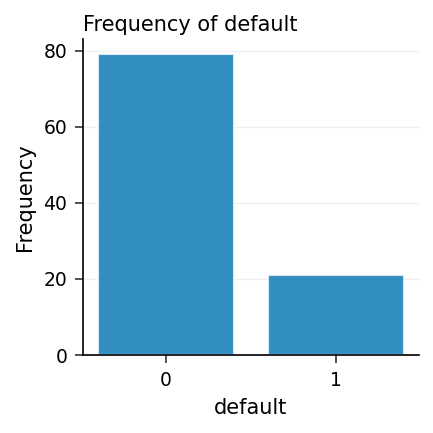

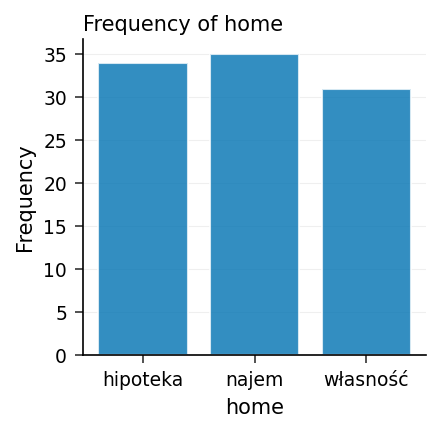

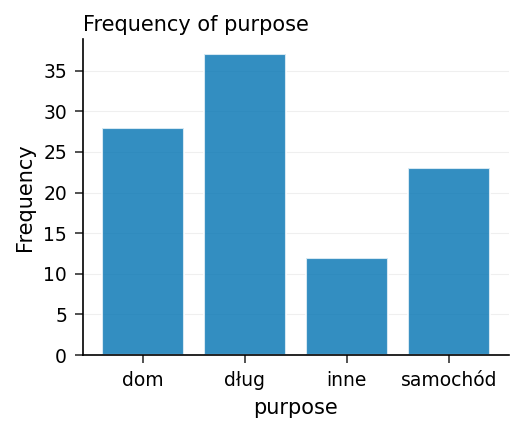

In [1]:
DANE applicants;
   CALL streaminit(20260531);
   DŁUGOŚĆ home $12 purpose $10;
   POWTÓRZ id = 1 TO 100;
      /* Profil finansowy pożyczkobiorcy */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Atrybuty kategorialne */
      u = rand('uniform');
      JEŚLI u < 0.34 WTEDY home = 'najem';
      PRZECIWNIE JEŚLI u < 0.70 WTEDY home = 'hipoteka';
      PRZECIWNIE home = 'własność';

      v = rand('uniform');
      JEŚLI v < 0.40 WTEDY purpose = 'dług';
      PRZECIWNIE JEŚLI v < 0.65 WTEDY purpose = 'dom';
      PRZECIWNIE JEŚLI v < 0.85 WTEDY purpose = 'samochód';
      PRZECIWNIE purpose = 'inne';

      /* Utajone ryzyko niewypłacalności: gorszy DTI/wykorzystanie/liczba
         opóźnień oraz niższe FICO / krótsza historia podnoszą log-szanse. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'najem')
            + 0.25 * (purpose = 'dług');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      USUŃ u v eta p;
      WYJŚCIE;
   KONIEC;
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=applicants;
   TABLES default home purpose / nocum;
   ETYKIETA default = "Niewypłacalność"
         home    = "Status mieszkaniowy"
         purpose = "Cel pożyczki";
WYKONAJ;

Wynik `PROC FREQ` potwierdza niezrównoważony, ale realistyczny wskaźnik niewypłacalności — mniej więcej co piąty wnioskodawca staje się niewypłacalny (21 na 100) — oraz sensowny rozkład w kategoriach statusu mieszkaniowego i celu pożyczki: dokładnie taki, jakiego można by oczekiwać w portfelu kredytów konsumenckich. Towarzyszące wykresy słupkowe wizualizują każdy z rozkładów brzegowych.

## 2. Hodowanie i przycinanie drzewa scorecardu

Modelujemy `default` jako binarny cel klasyfikacyjny, nazywając `event='1'`, tak aby wszystkie statystyki czułości/swoistości/AUC były zorientowane na klasę *niewypłacalności*. Wykonujemy:

- deklarację predyktorów kategorialnych i odpowiedzi w `CLASS`,
- hodowanie drzewa kryterium **entropii** (przyrostu informacji),
- przycinanie metodą **kosztu-złożoności**, aby drzewo nie zapamiętywało szumu,
- żądanie **diagramu całego drzewa** oraz **krzywej ROC**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Niewypłacalność
  Class variable: Niewypłacalność
  Class variable: Status mieszkaniowy
  Class variable: Cel pożyczki
  Predictor variable: Wskaźnik DTI
  Predictor variable: Wykorzystanie limitu
  Predictor variable: Wynik FICO
  Predictor variable: Wiek historii kredytowej
  Predictor variable: Liczba opóźnień
  Predictor variable: Kwota pożyczki
  Predictor variable: Dochód
  Predictor variable: Status mieszkaniowy
  Predictor variable: Cel pożyczki

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


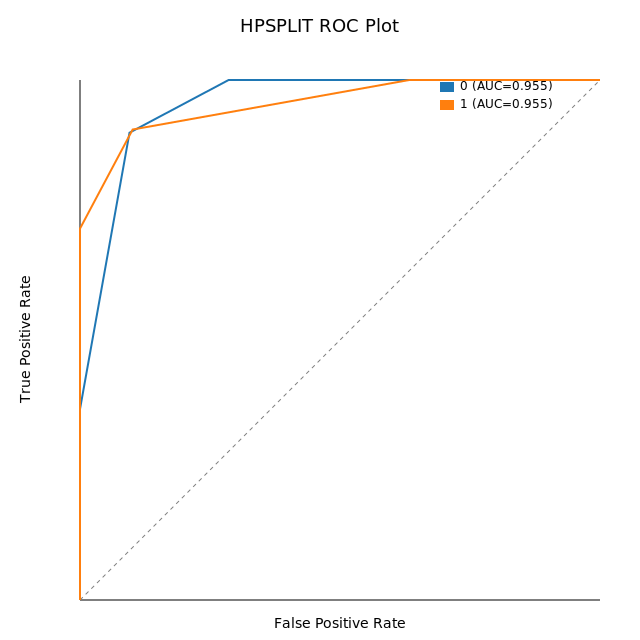

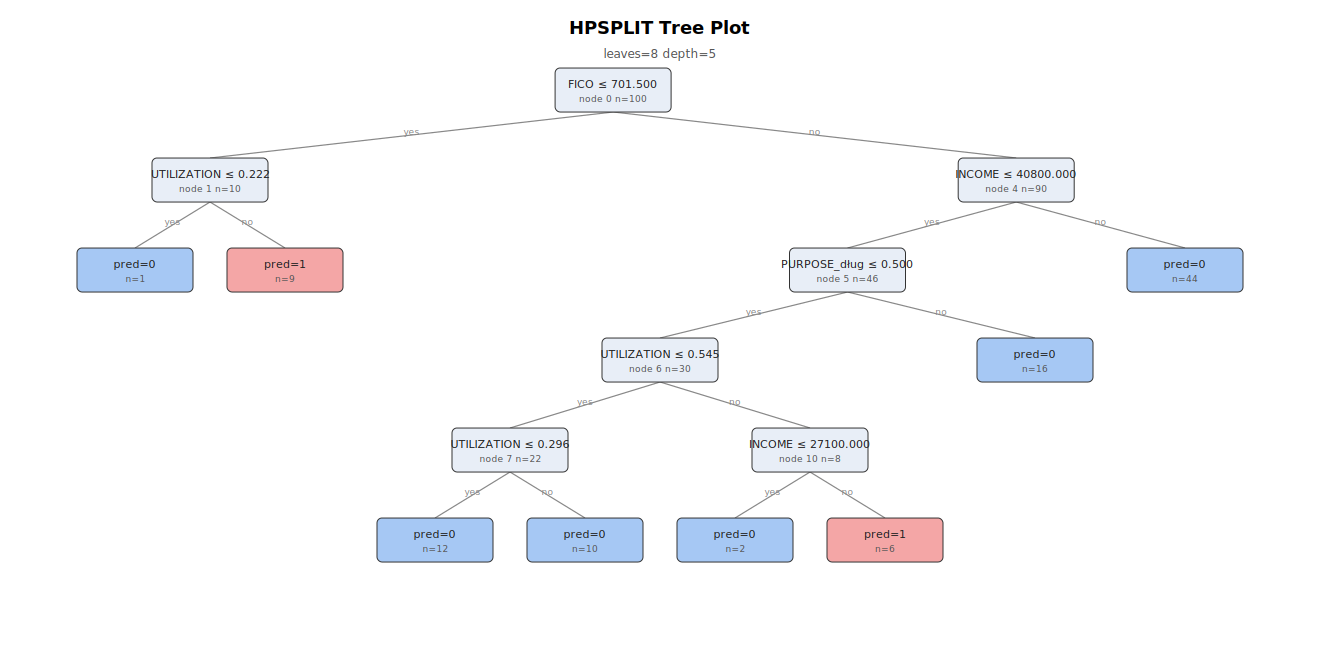

In [2]:
ODS GRAPHICS ON;

PROCEDURA hpsplit DANE=applicants seed=20260531
             PLOTS=(wholetree roc);
   KLASA default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   ETYKIETA default     = "Niewypłacalność"
         dti          = "Wskaźnik DTI"
         utilization  = "Wykorzystanie limitu"
         fico         = "Wynik FICO"
         credit_age   = "Wiek historii kredytowej"
         n_delinq     = "Liczba opóźnień"
         loan_amount  = "Kwota pożyczki"
         income       = "Dochód"
         home         = "Status mieszkaniowy"
         purpose      = "Cel pożyczki";
WYKONAJ;

**Statystyki dopasowania** (dokładność, wskaźnik błędnej klasyfikacji, log loss) oraz **ROC / AUC według klasy** pokazują, jak czysto przycięte drzewo rozdziela niewypłacalnych od niepodlegających niewypłacalności. Tabela **ważności zmiennych** rankinguje, które atrybuty napędzają podziały — tutaj dominują **wykorzystanie limitu** i **FICO**, a następnie **cel pożyczki**, dokładnie te dźwignie, które podkreślałaby polityka kredytowa. **Wykres całego drzewa** poniżej rozkłada wybrane podziały jako diagram węzłów-połączeń: każdy węzeł wewnętrzny pokazuje regułę `cecha ≤ próg`, a każdy liść jest kolorowany według przewidywanej klasy (czerwony = przewidywana niewypłacalność, niebieski = przewidywany brak niewypłacalności) i opisany liczbą obserwacji.

## 3. Przybliżenie kluczowych podziałów i ocena każdego wnioskodawcy

Powyższy wykres ROC wizualizuje kompromis między wychwytywaniem niewypłacalnych a fałszywymi alarmami; AUC kwantyfikuje ogólną moc rankingową. Następnie powiększamy dwa górne poziomy drzewa — podziały o najwyższej informacji, które analityk przełożyłby na główne zasady underwritingu — i przechwytujemy oceny na poziomie obserwacji do zbioru wyjściowego, aby móc audytować prognozy dalej.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Niewypłacalność
  Class variable: Niewypłacalność
  Class variable: Status mieszkaniowy
  Class variable: Cel pożyczki
  Predictor variable: Wskaźnik DTI
  Predictor variable: Wykorzystanie limitu
  Predictor variable: Wynik FICO
  Predictor variable: Wiek historii kredytowej
  Predictor variable: Liczba opóźnień
  Predictor variable: Kwota pożyczki
  Predictor variable: Dochód
  Predictor variable: Status mieszkaniowy
  Predictor variable: Cel pożyczki

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/7b454e3b-4716-44d7-9c69-bce87d74d3a2/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


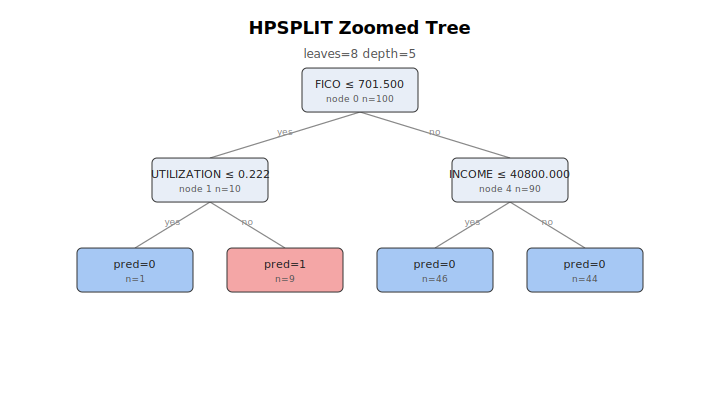

In [3]:
PROCEDURA hpsplit DANE=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   KLASA default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   WYJŚCIE out=scored;
   ETYKIETA default     = "Niewypłacalność"
         dti          = "Wskaźnik DTI"
         utilization  = "Wykorzystanie limitu"
         fico         = "Wynik FICO"
         credit_age   = "Wiek historii kredytowej"
         n_delinq     = "Liczba opóźnień"
         loan_amount  = "Kwota pożyczki"
         income       = "Dochód"
         home         = "Status mieszkaniowy"
         purpose      = "Cel pożyczki";
WYKONAJ;

PROCEDURA DRUKUJ DANE=scored(obs=10);
   ZMIENNA p_default1 _node_ _leaf_;
WYKONAJ;

Wykres `zoomedtree` powiększa dwa górne poziomy drzewa — podziały o najwyższej informacji, które analityk przełożyłby na główne zasady underwritingu. Zbiór `OUTPUT OUT=` przenosi przewidywane prawdopodobieństwo niewypłacalności każdego wnioskodawcy (`P_DEFAULT1`) wraz z przypisanym węzłem i liściem (`_NODE_`, `_LEAF_`), dzięki czemu zespoły ryzyka i audytu mogą prześledzić każdą indywidualną decyzję z powrotem przez drzewo i uszeregować wnioskodawców według modelowanego ryzyka.

## 4. Eksport kodu scoringowego gotowego do wdrożenia

Wartością modelu interpretowalnego jest to, że można go wdrożyć. `CODE FILE=` zapisuje samodzielny krok DATA — zagnieżdżony łańcuch podziałów `IF/THEN` kończący się przewidywanym prawdopodobieństwem i klasą niewypłacalności — który odtwarza wynik drzewa dla dowolnego nowego pliku wniosków bez potrzeby serwera modeli.

In [4]:
PROCEDURA hpsplit DANE=applicants seed=20260531;
   KLASA default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code file='credit_scorecard.sas';
   ETYKIETA default     = "Niewypłacalność"
         dti          = "Wskaźnik DTI"
         utilization  = "Wykorzystanie limitu"
         fico         = "Wynik FICO"
         credit_age   = "Wiek historii kredytowej"
         n_delinq     = "Liczba opóźnień"
         loan_amount  = "Kwota pożyczki"
         income       = "Dochód"
         home         = "Status mieszkaniowy"
         purpose      = "Cel pożyczki";
WYKONAJ;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Niewypłacalność
  Class variable: Niewypłacalność
  Class variable: Status mieszkaniowy
  Class variable: Cel pożyczki
  Predictor variable: Wskaźnik DTI
  Predictor variable: Wykorzystanie limitu
  Predictor variable: Wynik FICO
  Predictor variable: Wiek historii kredytowej
  Predictor variable: Liczba opóźnień
  Predictor variable: Kwota pożyczki
  Predictor variable: Dochód
  Predictor variable: Status mieszkaniowy
  Predictor variable: Cel pożyczki

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Interpretacja wyników

Przycięte drzewo entropii daje zespołowi ryzyka zwarty, audytowalny scorecard kredytowy:

- **Podziały kodują politykę.** Dominujące podziały — na wykorzystaniu limitu odnawialnego i FICO, następnie celu pożyczki i DTI — to dokładnie te progi, które zespół underwritingu może przenieść na twarde zasady odcięcia. Wykres całego drzewa rozkłada każdy warunek podziału i liść na jednym diagramie.
- **Przycinanie metodą kosztu-złożoności** chroni drzewo przed zapamiętywaniem szumu; statystyki dopasowania (dokładność, wskaźnik błędnej klasyfikacji, log loss) podsumowują, jak czysto rozdziela ono obie klasy.
- **Ważność zmiennych i ROC/AUC** uzasadniają, które atrybuty zasługują na miejsce w scorecardzie i dokumentują jego moc dyskryminacyjną dla nadzoru nad ryzykiem modelowym.
- **`CODE FILE=` czyni go operacyjnym** — wyeksportowany krok DATA ocenia nowych wnioskodawców identycznie jak ten przebieg, więc model, który zbudowano, jest dokładnie tym modelem, który idzie na produkcję.

Na małej księdze wnioskodawców drzewo dopasowuje się ściśle do danych treningowych; w produkcji hodowałoby się je na pełnym portfelu, odkładając partycję walidacyjną, kalibrując próg odcięcia prawdopodobieństwa do ekonomii oczekiwanej straty banku (koszt przeoczonej niewypłacalności w porównaniu z odrzuconym dobrym klientem), a nie naiwnym progiem 0,5, oraz odświeżając drzewo w miarę zmian miksu portfela.